In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Read the csv-file

In [3]:
# This is the data to do the EDA on.
df = pd.read_csv(r'C:\\Users\\ulfha\\PytonSrc\\Kunskapskontroller_lokal\\Kontroll3\\housing.csv')
#df = pd.read_csv(r'C:\\Users\\ulfha\\PytonSrc\\Kunskapskontroller_lokal\\Kontroll3\\housing.csv', nrows=10)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


### Om man nu granskar filens innehåll på en rad kan vi se kolumner som jag tolkar enligt följande:
* longitud, latitude: ett geografiskt område
* house_median_age: medianålder på husen i området
* totals_rooms: totalt antal rum i dessa hus
* total_bedrooms: totalt antal badrum i dessa hus
* population : antal personer som bor i dessa hus totalt, frågan är ju om det bara är ägaren eller barn mm ingår?
* households:  antal hushåll som omfattas av denna data/rad, låter som antal hus men det kan ju vara flerfamiljshus?
* median_income: median inkomst per hushåll, för alla eller bara ägaren?
* median_house_value: median husvärde i detta område
* ocean_proximity: läge relativt havet för detta område

### Vi börjar vår EDA här och naturligt är väl att kontrollera mot avstånd till havet, men kanske också och se på trångboddhet (personer per hushåll) samt antalet bostäder inom ett specifikt område (personer per position) samt titta på inkomstfördelning där längre fram. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Vi kan se att total_bedrooms har 207 null-värden (20640-20433). Viktigt att komma ihåg om nu detta fält skall användas. Generellt så tycker jag spridningen av alla värden grupperat av ocean_proximity ger en bättre översikt att titta på och ta var och en för sig. 

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Vi ser att max-raden innehåller data som känns värd att titta mer på, vi tittar närmare på dom längre ner. Väldigt många hushåll ex vis.

### Vi ser att kolumnen ocean_proximity är fördelat på en lämplig indelning av datan. Vi tittar vidare på den.

In [6]:
print(df["ocean_proximity"].unique())
print()
df_counts = df["ocean_proximity"].value_counts()
print(df_counts)

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### Vi ritar ett stapeldiagram och tittar hur det ser ut.

Text(0.5, 1.0, 'Distribution of ocean_proximity')

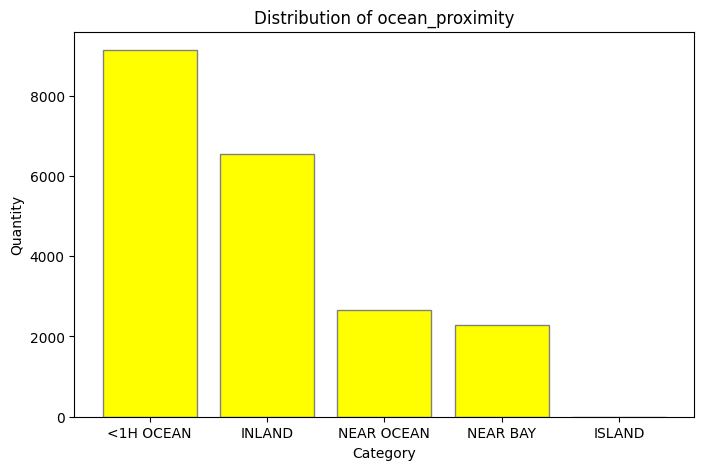

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(df_counts.index, df_counts.values, color="yellow", edgecolor="gray")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.title("Distribution of ocean_proximity")
#plt.show() # Behövs inte, den ritar ut själv


### Vi ritar ut histogram på beräkningsbara fält.

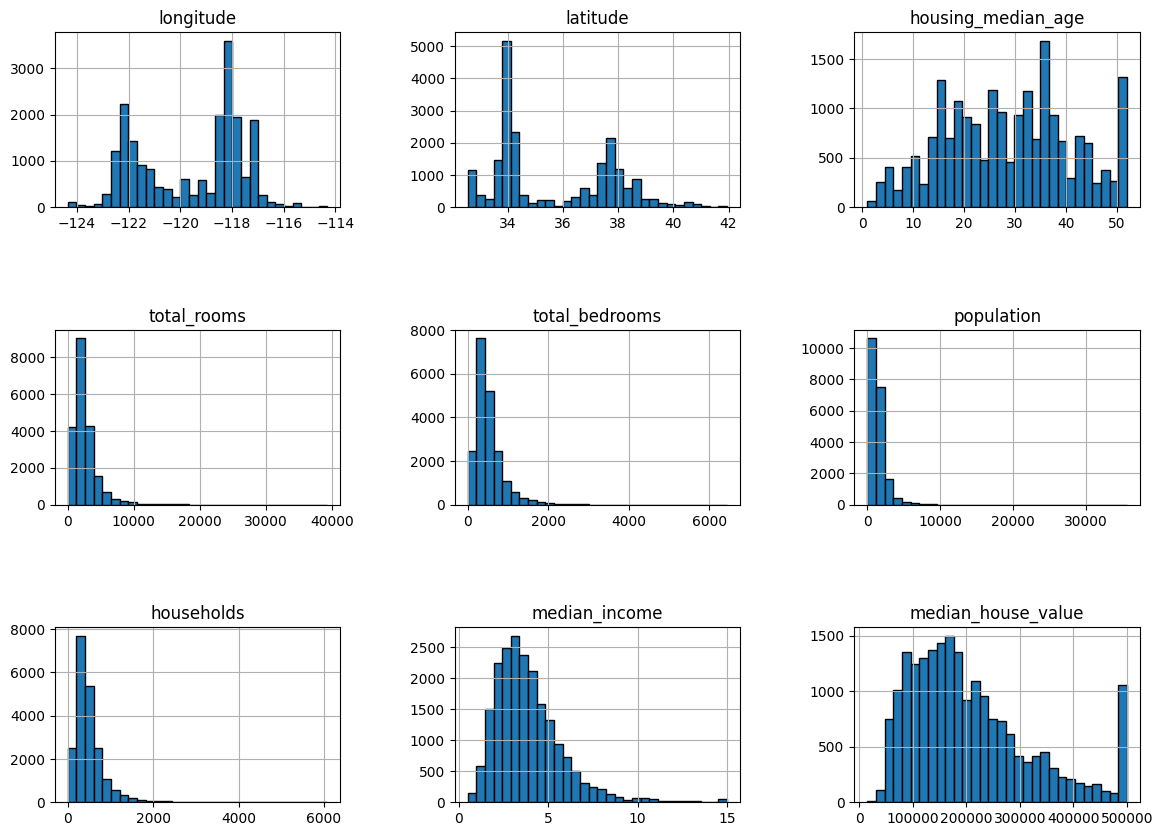

In [8]:
df.hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)


### Direkt kan vi se att median_house_value sticker ut på högsta värdet. Vi tittar vidare på det.

In [9]:
# Vi hämtar hur många hus som har medianvärde över 500000
df_mod = df.loc[(df['median_house_value']>500000)].value_counts()
df_mod


longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value  ocean_proximity
-122.64    37.96     29.0                377.0        58.0            151.0       67.0        9.5551         500001.0            NEAR OCEAN         1
-118.39    34.05     42.0                1467.0       203.0           577.0       204.0       6.6368         500001.0            <1H OCEAN          1
-118.40    34.09     45.0                2686.0       283.0           857.0       259.0       15.0001        500001.0            <1H OCEAN          1
           34.10     27.0                3979.0       510.0           1351.0      520.0       15.0001        500001.0            <1H OCEAN          1
           34.11     32.0                5578.0       753.0           1567.0      697.0       15.0001        500001.0            <1H OCEAN          1
                                                                                                         

### Det finns 958 hus med median_house_value på 500001. Detta värde är säkert ett schablonvärde som nog skall tolkas som takvärde i datainsamlingen dvs, 500000 eller mer. Då vi vill analysera husvärden är det ju fel att ha med dessa värden. Vi exkluderar dom.



### Vi ser att ISLAND endast har 5 st rader, vilket gör att vi exkluderar dom. Lämpligt är väl och titta på dom om dom sticker ut på något sätt.

In [10]:
df_mod= df.loc[(df['ocean_proximity']  =="ISLAND")]
df_mod

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8314,-118.32,33.35,27.0,1675.0,521.0,744.0,331.0,2.1579,450000.0,ISLAND
8315,-118.33,33.34,52.0,2359.0,591.0,1100.0,431.0,2.8333,414700.0,ISLAND
8316,-118.32,33.33,52.0,2127.0,512.0,733.0,288.0,3.3906,300000.0,ISLAND
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,450000.0,ISLAND
8318,-118.48,33.43,29.0,716.0,214.0,422.0,173.0,2.6042,287500.0,ISLAND


### Nej, jag kan inte se att det är något att ta hänsyn till. Vi utesluter ISLAND rader.
### Nu skall vi titta på fördelning av husvärden presenterat i bubbeldiagram.

In [11]:
# Detta är data vi behöver i vår funktion
our_colors = ('c','g','y','r') # Vi definerar lite färger 

# Vi ordnar en array med de 
df_areas= df["ocean_proximity"].unique() # vi har alla områden och vi kör igenom från 0-3 och hoppar över ISLANDS då det är för få
df_areas.sort(axis = 0) # Sortera den, df_areas är en numpy.ndarray
ret = np.where(df_areas == "ISLAND") # Hitta index för ISLAND
df_areas = np.delete(df_areas,[ret]) # Ta bort den ur listan


# Vi gör en funktion för att skriva ut bubbeldiagram
# Vi tar en kategori åt gången och ser i ett scatterdiagram hur det ser ut
# Vi får då arbeta explicit och lägga 4 diagram efter varandra sidledes


def print_bubbles(df_passed, field, axes_label, colors): # df_passed är dataframen, field är vilket fält vi vill ha på x-axeln. På y-axel är alltid hus-värdet sen en tuple med färger.
    """ df_passed is a dataframe with the query , 
        field is thethe field we want on the X-axis, 
        axes_label is the name of x-axis,
        colors is atuple with color selection of bubbles."""
    fig, axs = plt.subplots(1,4, figsize=(18, 8)) # Skapa en fig som har 4 st diagram i bredd
    for r in range(df_areas.size):
        df_mod= df_passed.loc[df_passed['ocean_proximity'] == df_areas[r]] # Arbeta med en i taget av INLAND, NEAR BAY etc..
        axs[r].scatter(df_mod[field], df_mod['median_house_value'], alpha=0.5, edgecolor=colors[r]) # Skriv ut värdet på x-axeln vad vi mäter
        axs[r].set_title(df_areas[r], fontsize=14)
        axs[r].set_xlabel(f'{axes_label,df_mod.shape[0]} pts', fontsize=12) # Skriv ut varder och hur många mätpunkter det avser
        axs[r].set_ylabel('Median House Value', fontsize=12) # Y är alltid hus-värdet här

        


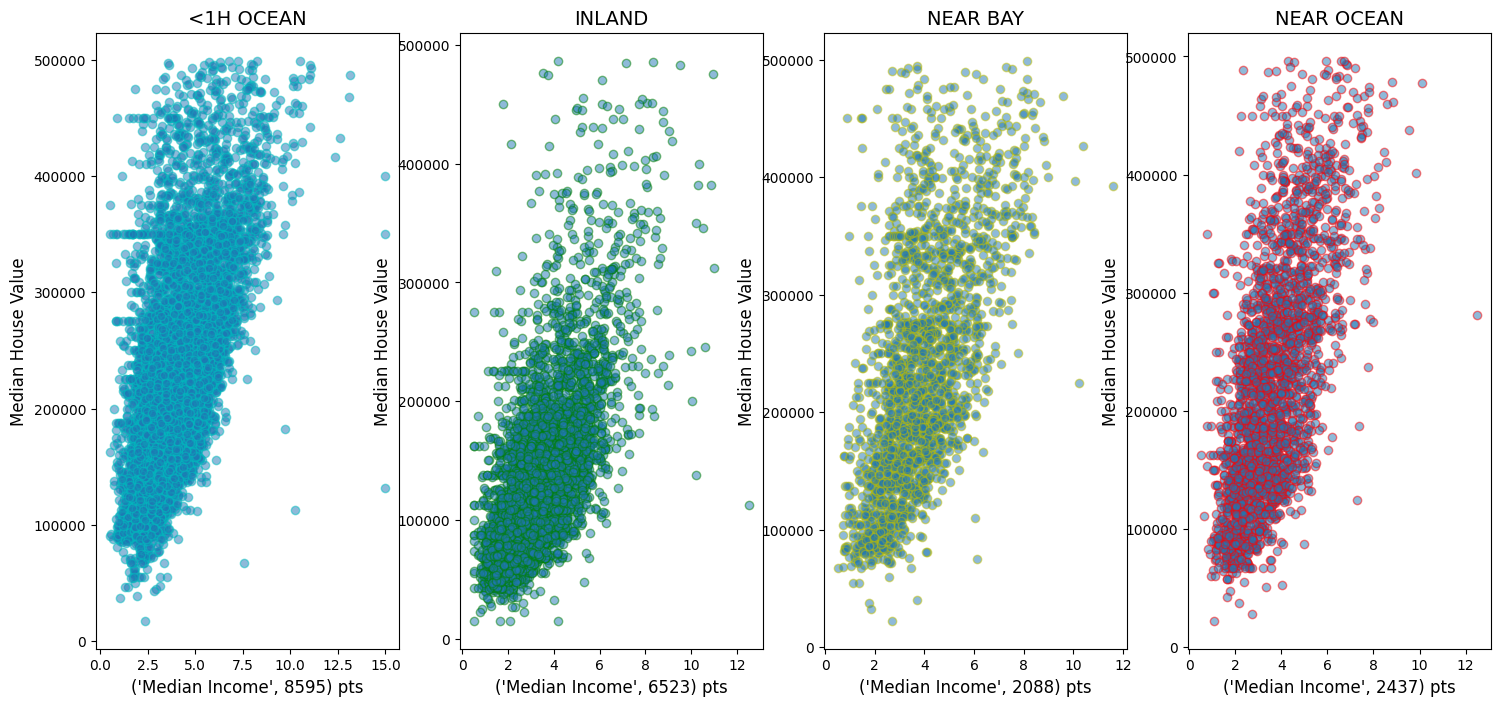

In [12]:
# Nedan tittar vi på på husvärde vs inkomst
df_mod = df.loc[(df['median_house_value']<500000)]  # Inte värden över 500000
print_bubbles(df_mod,'median_income', "Median Income", our_colors)




### Ovan kan man se en förtätningen av mätpunkter för hus med lägre medianvärde finns i INLAND och att spridningen på INCOME är tätare längre ner. 
### För <1 OCEAN kan vi se en mer tydlig  "strutformad" utveckling inkomst och husvärden följer varandra mer.


### Nedan skall vi titta på hur stora hushåll eller hur många det bor i hushållen och mäta det mot inkomst.

Lost rows: 1001


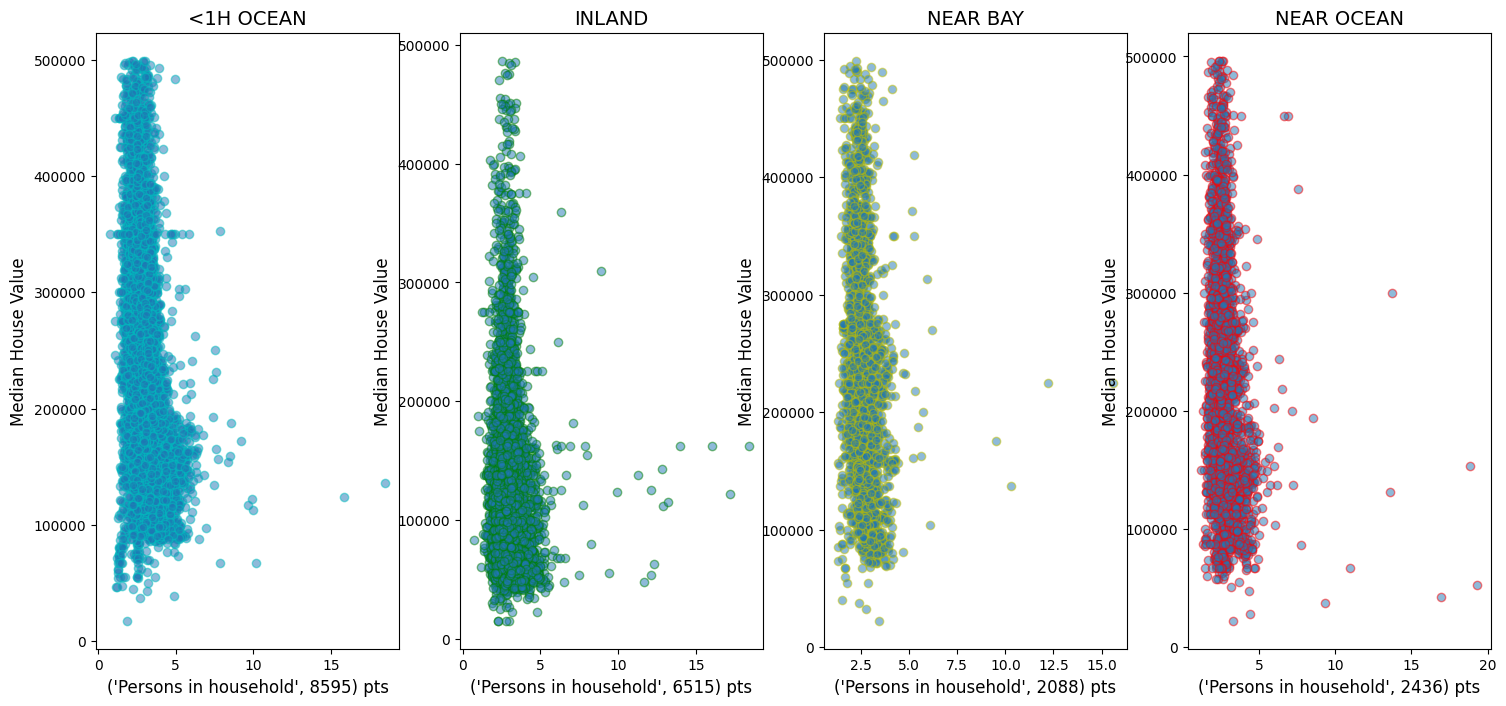

In [13]:
# Skapar ett nytt fält med personer i hushållet och tittar hur det ser ut

df['avg_persons_in_household'] = df['population'] / df['households']
# I detta urval finns det data som känns fel, vilket gör att vi väljer och kolla på de hus med mindre än 20 personer
df_mod= df.loc[(df['avg_persons_in_household']<20) & (df['median_house_value']<500000)]
removed = df.shape[0]-df_mod.shape[0]
print(f'Lost rows: {removed}') # Vi tappar 1001 st, men x-axeln på diagrammen blir bättre


print_bubbles(df_mod,'avg_persons_in_household', "Persons in household", our_colors)

### Ovan visar storleken på hushållen mot husens värden i de olika områdena. Den spridning som finns (antal hushåll>7 pers känns konstigt) gör väl att man ser att det inte borde röra sig om villor utan även andra fastigheter. Eller så är det fel data vi arbetar med. Spridningen för INLAND kan kanske tolkas att det finns lantbruk mm i de områdena. Värt att notera att X-skalan för NEAR OCEAN är graderad till 20. Jag vet inte om detta urval ger något vettigt!!!



### Nedan skall vi titta vidare på husvärden mot antal rum. Vi exkluderar att kolla fastigheter över 20 rum.

Max no of rooms:141.9090909090909
Lost rows: 1060


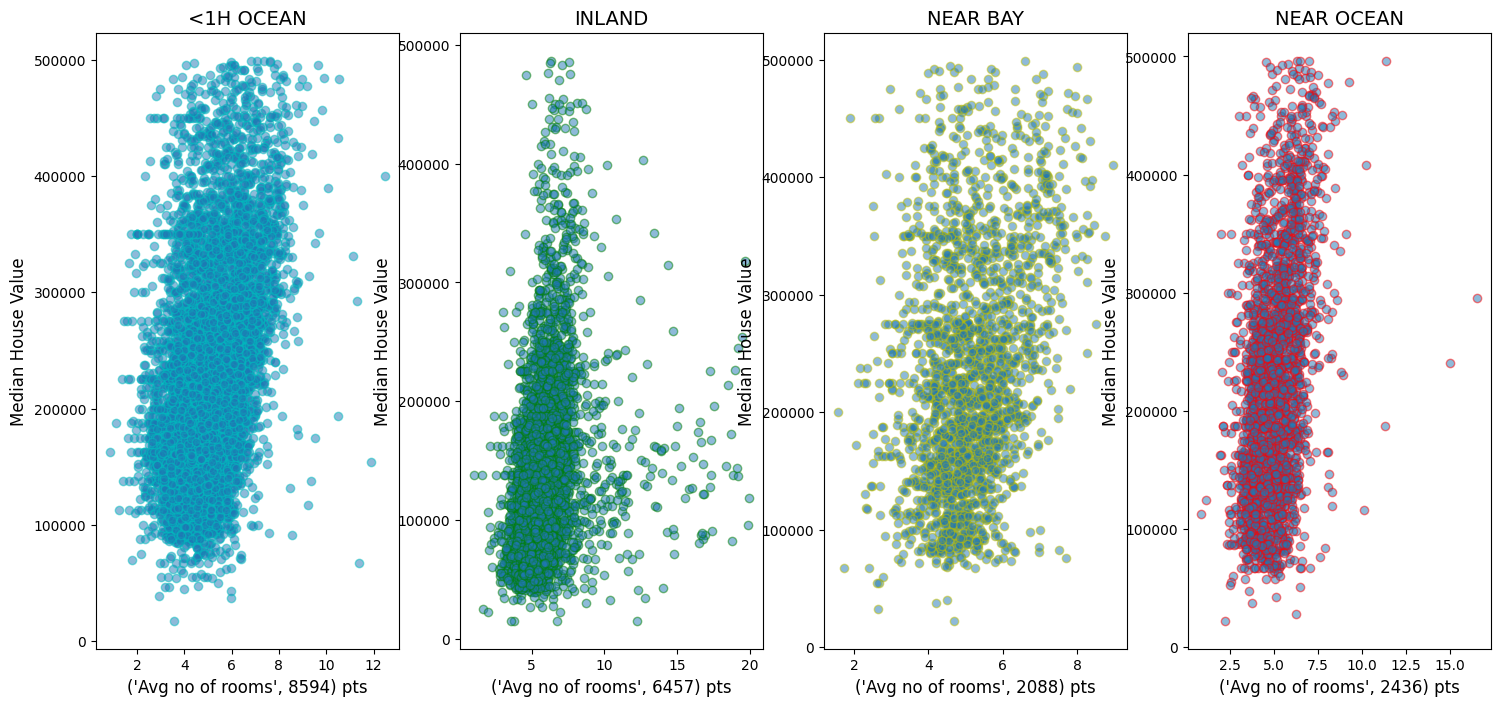

In [14]:
# Intressant är ju också att titta på husvärden beroenden på antal rum
# Vi skapar ett nytt fält för det

df['avg_no_of_rooms'] = df['total_rooms'] / df['households']

print(f'Max no of rooms:{df['avg_no_of_rooms'].max()}')  # Det finns ett max antal som är 141 vilket är orinmligt
                                    # så vi begänsar oss till de som har max 20 rum
df_mod= df.loc[(df['avg_no_of_rooms']<20) & (df['median_house_value']<500000)]

removed = df.shape[0]-df_mod.shape[0]
print(f'Lost rows: {removed}') # Vi tappar 1060 st, men x-axeln på diagrammen blir bättre

print_bubbles(df_mod,'avg_no_of_rooms', "Avg no of rooms", our_colors)


### Vi ser att spridningen för NEAR BAY är bredare, men X-axelns skala är satt till 10 där. I INLAND verkar ha det finnas flest stora hus och husvärdena centrerad lägre. <1H OCEAN har mest homogena husvärdena och mest lika i antal rum, kanske lägenheter med havsutsikt. Även NEAR OCEAN är mer homogent samlad.



### Jag tycker det är konstigt med hur många rum varje fastighet har. Nedan tittar vi på hur många som har mer än 30 rum.

In [15]:

df_mod= df.loc[(df['avg_no_of_rooms']>30) & (df['median_house_value']<500000)]


print(df_mod.shape)
print(df_mod.value_counts(['ocean_proximity']))
 # 23 st i INLAND har det
 # Vi tittar på hur de ser ut

df_mod.tail(30)


(23, 12)
ocean_proximity
INLAND             23
Name: count, dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,avg_persons_in_household,avg_no_of_rooms
1102,-121.54,40.06,17.0,858.0,262.0,47.0,27.0,2.4028,67500.0,INLAND,1.740741,31.777778
1239,-120.27,38.31,13.0,3297.0,662.0,267.0,97.0,3.0750,108300.0,INLAND,2.752577,33.989691
1240,-120.19,38.42,11.0,1568.0,369.0,82.0,33.0,3.1250,77500.0,INLAND,2.484848,47.515152
1872,-119.93,38.94,27.0,1709.0,408.0,97.0,44.0,2.4917,200000.0,INLAND,2.204545,38.840909
1912,-120.16,39.01,16.0,1463.0,264.0,54.0,26.0,4.9750,206300.0,INLAND,2.076923,56.269231
1913,-120.06,39.01,19.0,2967.0,528.0,112.0,48.0,4.0714,437500.0,INLAND,2.333333,61.812500
1926,-120.30,38.90,11.0,1961.0,435.0,113.0,53.0,0.9227,95500.0,INLAND,2.132075,37.000000
1978,-120.32,38.71,13.0,1115.0,255.0,86.0,32.0,3.5667,115600.0,INLAND,2.687500,34.843750
1979,-120.08,38.80,34.0,1988.0,511.0,36.0,15.0,4.6250,162500.0,INLAND,2.400000,132.533333
2395,-119.34,37.12,23.0,1881.0,380.0,64.0,37.0,3.8750,125000.0,INLAND,1.729730,50.837838


### Alla är i INLAND och är säkert lantbruk osv. Många rum mot relativt få personer.

### Vi tittar på antalet i total_bedrooms och se vad det kan ge oss.

In [16]:
df['avg_no_of_bedrooms'] = df['total_bedrooms'] / df['households']

print(f'Rader under 1    :{df.loc[(df['avg_no_of_bedrooms']  <= 1)].shape[0]}')
print(f'Rader mellan 1-2 :{df.loc[((df['avg_no_of_bedrooms']  > 1) & (df['avg_no_of_bedrooms']  <= 2))].shape[0]}')
print(f'Rader över 2     :{df.loc[(df['avg_no_of_bedrooms']  > 2)].shape[0]}')

# Det finns 20433 utan nullvärden i total_bedroom. Pandas hanterar att inte räkna med dom

# df_mod.tail(30)

Rader under 1    :4640
Rader mellan 1-2 :15558
Rader över 2     :235


### Ovan urval ger utan att vi tar bort de med median_house_value >500000:
* avg_no_of_bedrooms  <= 1  ger 4640 st rader, dvs mindre än 1 sovrum per hushåll de flesta i <1H OCEAN. Kanske studiolägenheter.
* avg_no_of_bedrooms  1-2 ger 15558 st rader
* avg_no_of_bedrooms  >2 ger 235 st rader
### Total blir det 20433 st vilket stämmer med tidigare borträkning för nullvärden.

### Flest förekomster finns det i bed_rooms 1-2 så vi hämtar ett urval på detta och exkluderar de som hade husvärde >500000 så vi slipper den övre förtätningen som inte borde ingå då de raderna inte kan följa husens värden.

### Vi tittar på en info() för säkerhets skull.

In [17]:
# Hämta de i intervallet 1-2 och tar bort husvärdet över 500000 
df_mod = df.loc[((df['avg_no_of_bedrooms']  > 1) & (df['avg_no_of_bedrooms']  <= 2) & (df['median_house_value']  < 500000))]
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14787 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 14787 non-null  float64
 1   latitude                  14787 non-null  float64
 2   housing_median_age        14787 non-null  float64
 3   total_rooms               14787 non-null  float64
 4   total_bedrooms            14787 non-null  float64
 5   population                14787 non-null  float64
 6   households                14787 non-null  float64
 7   median_income             14787 non-null  float64
 8   median_house_value        14787 non-null  float64
 9   ocean_proximity           14787 non-null  object 
 10  avg_persons_in_household  14787 non-null  float64
 11  avg_no_of_rooms           14787 non-null  float64
 12  avg_no_of_bedrooms        14787 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.6+ MB


### Inga null värden där, bra.

### Vi ritar ut ett histogram med den data vi fått till nu utifrån vårt urval.

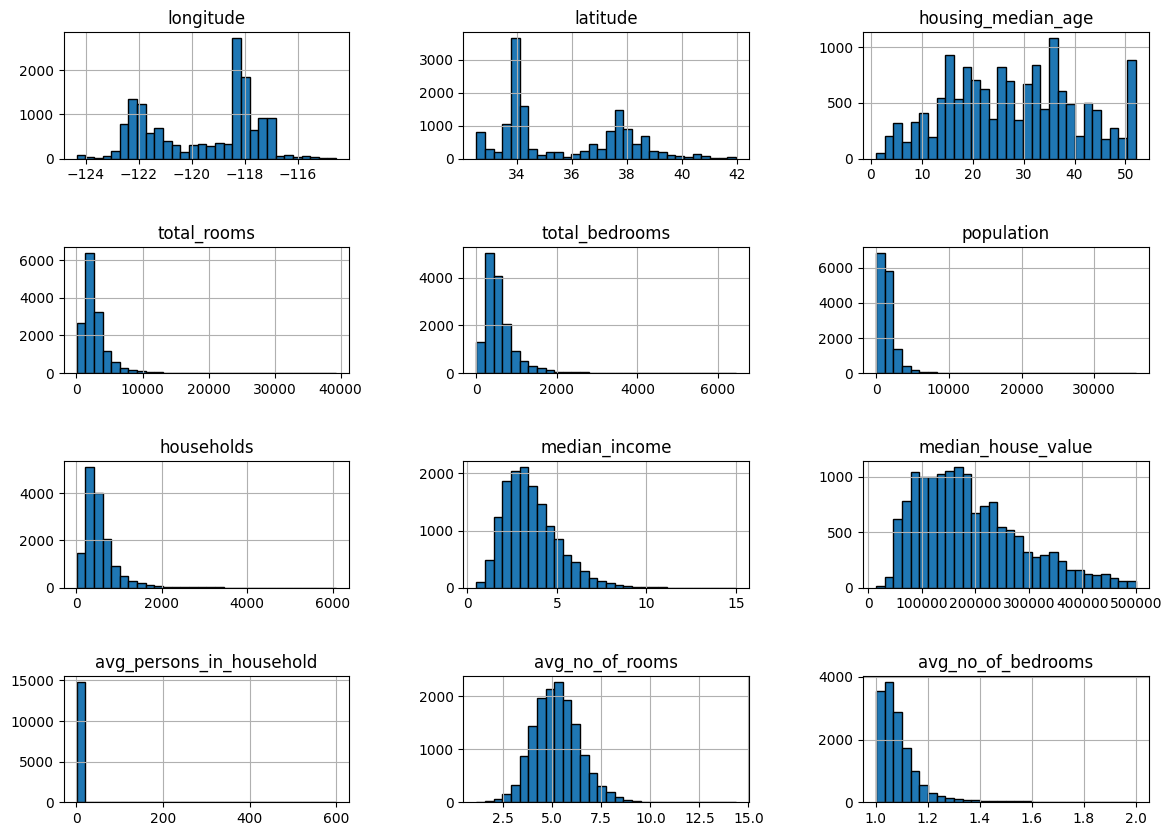

In [18]:

df_mod.hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)


### Kan väl inte se något som sticker ut nu.

### Om vi nu tittar på inkomsten utifrån det urvalskriterier vi fått och ser hur det ser ut.

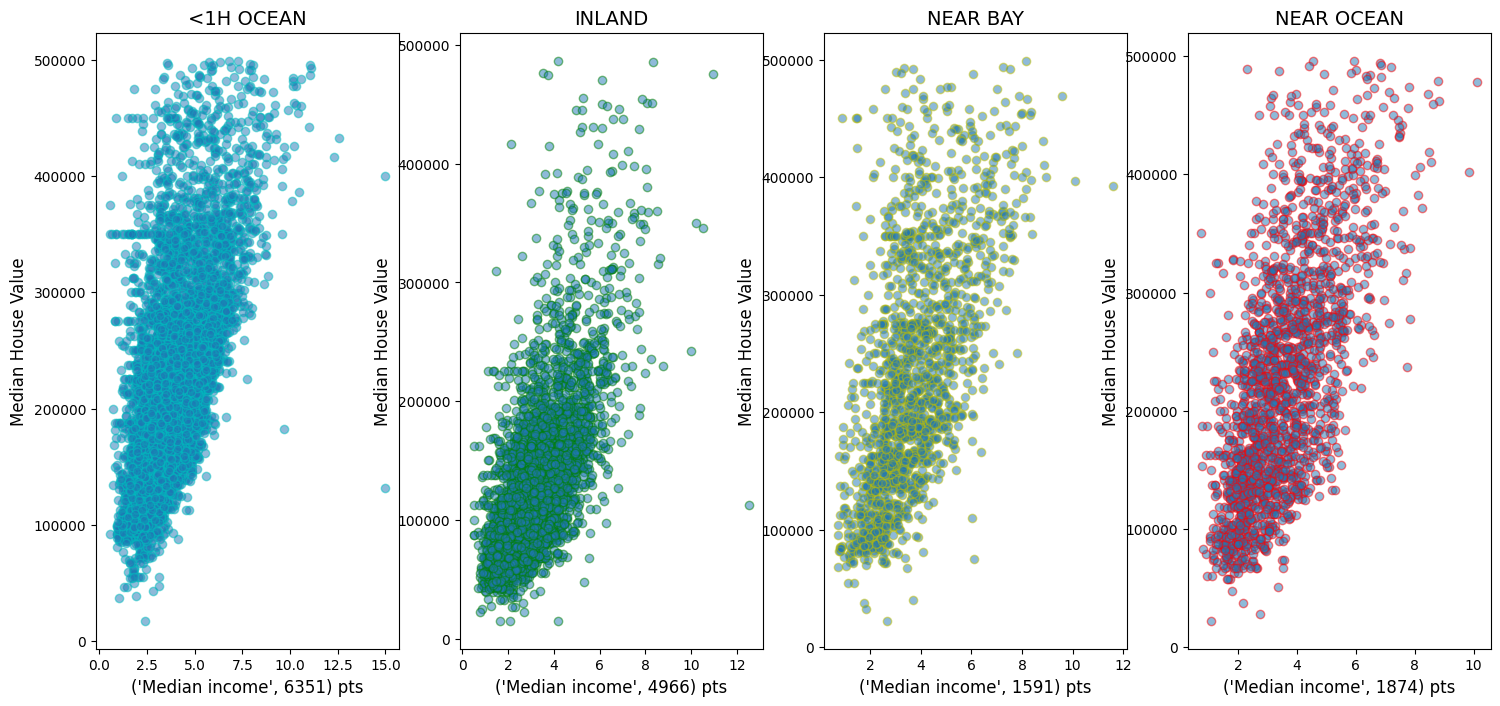

In [19]:
# Nu ritar vi ut ett bubbeldiagram i det intervallet
print_bubbles(df_mod,'median_income', "Median income", our_colors)



### Nu ser vi att INLAND har en förtätning i husvärden kring 100000-200000 medan <1 OCEAN är mer homogen. 

### Jag tror nog att vi hittat en ganska bra spridning av värdefördelningen av huspriserna. Man kan ju se i <1 OCEAN i höjd med 350000 ett konstigt rak ansamling i X-led, men det kan ju vara en slump.

### Men vi tittar på det.

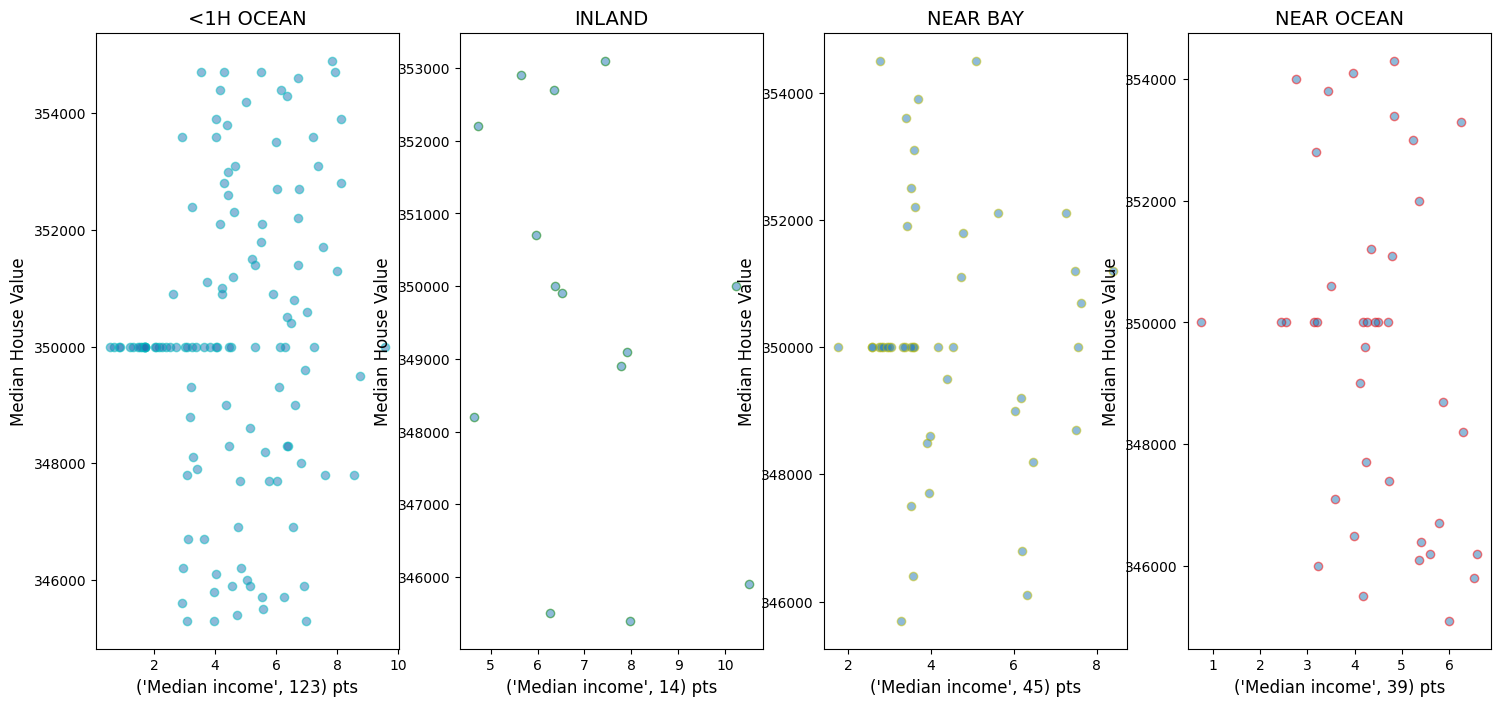

In [20]:
df_mod = df.loc[((df['avg_no_of_bedrooms']  > 1) & (df['avg_no_of_bedrooms']  <= 2) & (df['median_house_value']  < 355000) & (df['median_house_value']  > 345000))]
print_bubbles(df_mod,'median_income', "Median income", our_colors)

### Mycket riktigt, här är något. Men det är 65 st så det kanske inte är något fel, men vi är medvetna om att dom är där.

In [21]:
df_mod = df.loc[((df['avg_no_of_bedrooms']  > 1) & (df['avg_no_of_bedrooms']  <= 2) & (df['median_house_value']  < 351000) & (df['median_house_value']  > 349000))]
df_mod.value_counts(['median_house_value'])


median_house_value
350000.0              65
350900.0               3
349300.0               2
349500.0               2
349600.0               2
350600.0               2
350700.0               2
349100.0               1
349200.0               1
349900.0               1
350400.0               1
350500.0               1
350800.0               1
Name: count, dtype: int64

### Ritar vi ut på kartan så kan vi ju se utifrån att vi vet hur Californiens kust ser ut att de dyraste husen finns vid kusten, vilket ju kan kännas naturligt.

<Axes: xlabel='longitude', ylabel='latitude'>

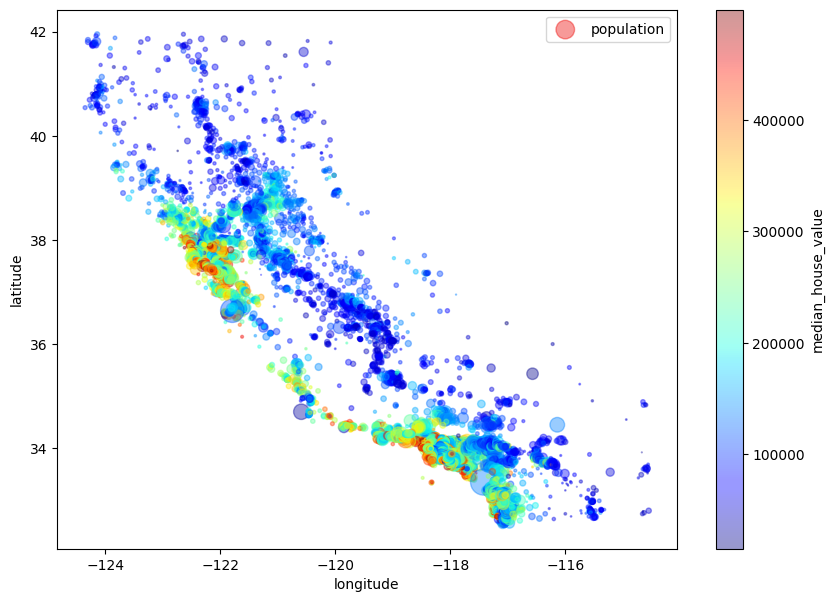

In [22]:
# Vi gör om vår dataframe
df_mod = df.loc[((df['avg_no_of_bedrooms']  > 1) & (df['avg_no_of_bedrooms']  <= 2) & (df['median_house_value']  < 500000))]

df_mod.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=df_mod["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)

In [ ]:
# Vi tittar en sista gång schematiskt på hur det ser ut
df_mod

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,avg_persons_in_household,avg_no_of_rooms,avg_no_of_bedrooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2.555556,6.984127,1.023810
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2.802260,8.288136,1.073446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2.547945,5.817352,1.073059
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2.181467,6.281853,1.081081
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,2.139896,4.761658,1.103627
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2.560606,5.045455,1.133333
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,3.122807,6.114035,1.315789
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2.325635,5.205543,1.120092
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2.123209,5.329513,1.171920


## Nu känns det som om jag har avslöjat det mesta av denna data. Finns säkert något missat men jag känner mig ganska nöjd. Men det känns som det data vi har nu omfattar "vanliga" bostäder. Ytterligheter som verkade finnas förut är nu borta i urvalet. 

# Nu till frågorna
## 1 : Om något varit utmanande?
### Jaa, det har varit utmanande. Men det har gått lättare än vid tidigare studier i livet. Vad som jag förstod nu var att tidigt göra uppgifter och inte vänta tills det varit för sent. Jag gjort alla uppgifter som vi tilldelats i tid utan fusk och därför inte känt stress över det. Det har väl egentligen inte varit direkt svårt, jag har ju arbetat med programmering i 40 år så jag vet hur man tar sig fram. Disciplin, erfarenhet och vana att läsa hjälp-filer osv. Sen finns ju google också. Har nog också en känsla för att veta vad jag söker och blir då mer "träffsäker" i mitt letande. Men jag har blivit imponerad över hur händig Python och Juypiter är, fantastiskt. Jag är road av allt detta vilket gör att det inte känns tungt.

## 2 : Vilket betyg jag borde få?
### Det är ju alltid svårt att framhäva sig själv, men jag tycker jag borde få ett MVG. I våra kontrolluppgifter har jag har visat att jag skrivit koden själv, det är inte kopierat. Likaså finns texter och kommentarer som visar att jag kunnat beskriva vad jag gör och sedan fått fram. På våra lektioner har jag visat att jag deltagit och följt med och frågat och varit aktiv. Kort sagt att jag behärskar det jag förväntas göra utifrån det vi gått igenom i kursen och haft engagemang för det. Jag har lagt ner mycket tid och testat koda vid sidan om och tyvärr haft lite konstigheter i utvecklingsmiljön som jag löst. Jag har ju en vana att arbeta med sådant sedan tidigare. Jag tycker också att jag tolkat datan i exemplet ovanför med housing på ett initiativ-fullt sätt och bearbetat det utan att begränsas utifrån vad jag borde ha tillskansat mig kunskap för.

## 3 : Något att lyfta fram till Terese?
### Du har varit väldigt bra, möjligen att framföra tydligt i början av kursen att man till varje lektion skall se till och ha gjort de uppgifter man blivit ålagd. När vi sätts i "rummen" och skall diskutera blir det ganska ointressant när i bästa fall en annan gjort klart uppgifterna. Det finns ju inte så mycket att diskutera om inte alla ens läst frågorna. Även om folk har ett arbete vid sidan om så skall de, av respekt mot andra, göra så gott man kan. Dom har ju själva valt att gå kursen. Så, tydligare instruktion av det. Annars är allt toppen tycker jag. Skönt att böckerna är skrivna på svenska.


